In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/raw/flights.csv', low_memory=False)
airlines = pd.read_csv('data/raw/airlines.csv')
airports = pd.read_csv('data/raw/airports.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/flights.csv'

In [3]:
import os
print(os.getcwd())

C:\Users\anish\flight_disruption_project\notebook


In [4]:
base_path = r"C:\Users\YourName\Documents\flight_disruption_project"

df       = pd.read_csv(f"{base_path}\\data\\raw\\flights.csv", low_memory=False)
airlines = pd.read_csv(f"{base_path}\\data\\raw\\airlines.csv")
airports = pd.read_csv(f"{base_path}\\data\\raw\\airports.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\YourName\\Documents\\flight_disruption_project\\data\\raw\\flights.csv'

In [7]:
import os

# Set this to your project folder
os.chdir(r"C:\Users\anish\Documents\flight_disruption_project")

# Confirm it worked
print("Working directory:", os.getcwd())

FileNotFoundError: [WinError 2] The system cannot find the file specified: 'C:\\Users\\anish\\Documents\\flight_disruption_project'

In [9]:
import os

base = r"C:\Users\anish\Documents\flight_disruption_project"

# Check each file exists
for f in ['data/raw/flights.csv', 'data/raw/airlines.csv', 'data/raw/airports.csv']:
    full = os.path.join(base, f)
    exists = os.path.exists(full)
    print(f"{'✓' if exists else '✗'} {full}")

✗ C:\Users\anish\Documents\flight_disruption_project\data/raw/flights.csv
✗ C:\Users\anish\Documents\flight_disruption_project\data/raw/airlines.csv
✗ C:\Users\anish\Documents\flight_disruption_project\data/raw/airports.csv


In [10]:
import os

home = os.path.expanduser("~")
base = os.path.join(home, "Documents", "flight_disruption_project")

# Show everything inside the project folder
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"  {indent}{file}")

In [11]:
import os

home = os.path.expanduser("~")
print("Your home folder is:", home)
print()

# List everything in your Documents folder
docs = os.path.join(home, "Documents")
print("Contents of Documents folder:")
for item in os.listdir(docs):
    print(" -", item)

Your home folder is: C:\Users\anish

Contents of Documents folder:
 - .Rhistory
 - anaconda_projects
 - Custom Office Templates
 - desktop.ini
 - My Music
 - My Pictures
 - My Videos
 - Output1.spv


In [12]:
import os

home = os.path.expanduser("~")
print("Searching for CSV files... (this may take 30 seconds)")

found = []
for root, dirs, files in os.walk(home):
    # Skip hidden and system folders to speed up search
    dirs[:] = [d for d in dirs if not d.startswith('.') 
               and d not in ['AppData', 'anaconda3', 'miniconda3']]
    for file in files:
        if file in ['flights.csv', 'airlines.csv', 'airports.csv']:
            found.append(os.path.join(root, file))

if found:
    print("\nFound these files:")
    for f in found:
        print(" ✓", f)
else:
    print("\nFiles not found anywhere in your user folder.")
    print("Please download them from Kaggle first.")

Searching for CSV files... (this may take 30 seconds)

Found these files:
 ✓ C:\Users\anish\datamining\airlines.csv
 ✓ C:\Users\anish\datamining\airports.csv
 ✓ C:\Users\anish\datamining\flights.csv
 ✓ C:\Users\anish\flight_disruption_project\data\raw\airlines.csv
 ✓ C:\Users\anish\flight_disruption_project\data\raw\airports.csv
 ✓ C:\Users\anish\flight_disruption_project\data\raw\flights.csv


In [13]:
import os
os.chdir(r"C:\Users\anish\flight_disruption_project")
print("Working directory:", os.getcwd())

Working directory: C:\Users\anish\flight_disruption_project


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df       = pd.read_csv('data/raw/flights.csv', low_memory=False)
airlines = pd.read_csv('data/raw/airlines.csv')
airports = pd.read_csv('data/raw/airports.csv')

print("Flights shape:", df.shape)
print("Airlines shape:", airlines.shape)
print("Airports shape:", airports.shape)

Flights shape: (5819079, 31)
Airlines shape: (14, 2)
Airports shape: (322, 7)


In [17]:
print("Column names:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

Column names:
 ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

Missing values:
 YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME 

In [18]:
df['ARRIVAL_DELAY']   = pd.to_numeric(df['ARRIVAL_DELAY'], errors='coerce')
df['DEPARTURE_DELAY'] = pd.to_numeric(df['DEPARTURE_DELAY'], errors='coerce')
df['CANCELLED']       = pd.to_numeric(df['CANCELLED'], errors='coerce').fillna(0)

print("Conversion done")
print(df[['ARRIVAL_DELAY','DEPARTURE_DELAY','CANCELLED']].describe())

Conversion done
       ARRIVAL_DELAY  DEPARTURE_DELAY     CANCELLED
count   5.714008e+06     5.732926e+06  5.819079e+06
mean    4.407057e+00     9.370158e+00  1.544643e-02
std     3.927130e+01     3.708094e+01  1.233201e-01
min    -8.700000e+01    -8.200000e+01  0.000000e+00
25%    -1.300000e+01    -5.000000e+00  0.000000e+00
50%    -5.000000e+00    -2.000000e+00  0.000000e+00
75%     8.000000e+00     7.000000e+00  0.000000e+00
max     1.971000e+03     1.988000e+03  1.000000e+00


Results folder created!


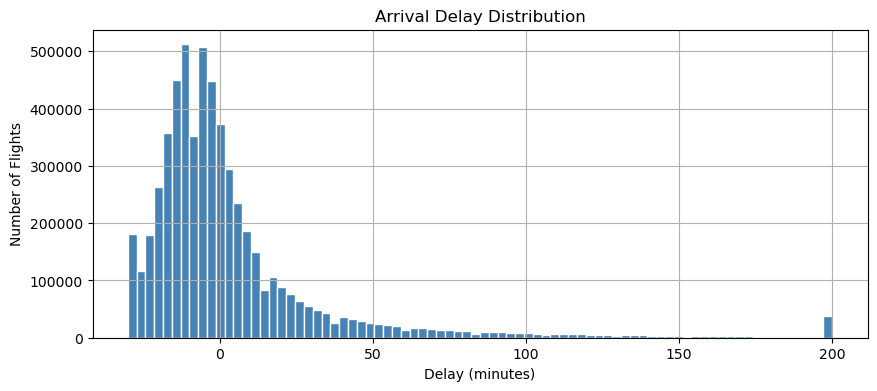

Plot saved!


In [23]:
import os
os.makedirs('results', exist_ok=True)
print("Results folder created!")

plt.figure(figsize=(10,4))
df['ARRIVAL_DELAY'].clip(-30, 200).hist(bins=80, color='steelblue', edgecolor='white')
plt.title('Arrival Delay Distribution')
plt.xlabel('Delay (minutes)')
plt.ylabel('Number of Flights')
plt.savefig('results/delay_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

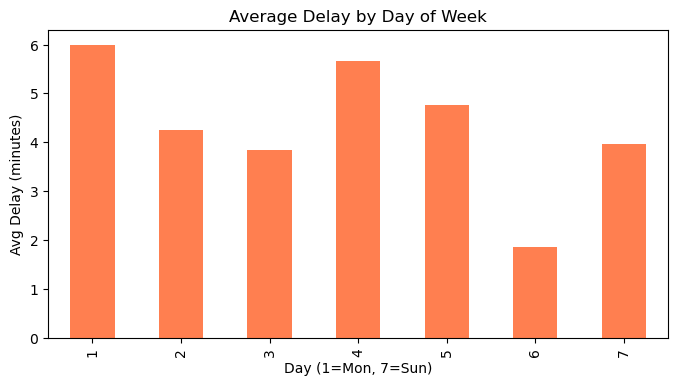

In [24]:
plt.figure(figsize=(8,4))
df.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean().plot(kind='bar', color='coral')
plt.title('Average Delay by Day of Week')
plt.xlabel('Day (1=Mon, 7=Sun)')
plt.ylabel('Avg Delay (minutes)')
plt.savefig('results/delay_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

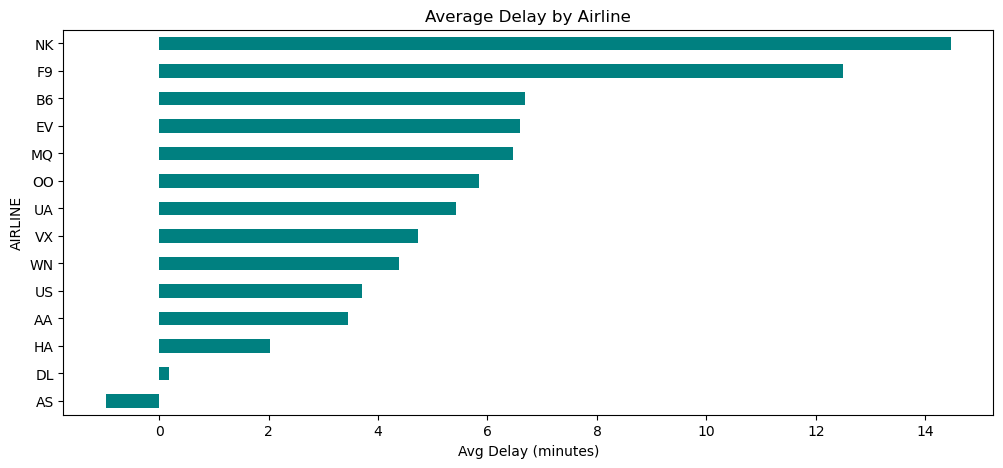

In [25]:
plt.figure(figsize=(12,5))
df.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values().plot(
    kind='barh', color='teal')
plt.title('Average Delay by Airline')
plt.xlabel('Avg Delay (minutes)')
plt.savefig('results/delay_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()